# 고객 활동 빈도 분석

확인할 내용:

- 고객별 하루 거래 횟수
- 고객별 일평균/최대 거래 횟수
- 요일별 거래 패턴
- 비정상적으로 잦은 결제 후보

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display
from matplotlib import font_manager

In [2]:
# 한글 폰트 설정
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

display(HTML("""
<style>
.jp-Notebook { font-size: 13px; }
.jp-RenderedMarkdown { font-size: 13px; line-height: 1.55; }
.jp-RenderedMarkdown h1 { font-size: 22px; }
.jp-RenderedMarkdown h2 { font-size: 17px; }
.jp-RenderedMarkdown h3 { font-size: 15px; }
.jp-OutputArea-output, .jp-RenderedText, .jp-OutputArea pre { font-size: 12px; }
.dataframe { font-size: 11px; }
</style>
"""))

## 1. 데이터 로드

현재 프로젝트에서는 `data/credit_card_transactions.csv`가 없을 수 있으므로, 없으면 `step1/data/credit_card_transactions.csv`를 자동으로 사용합니다.

In [3]:
def get_data_path():
    current_dir = Path.cwd()
    candidates = [
        current_dir / "data" / "credit_card_transactions.csv",
        current_dir / "step1" / "data" / "credit_card_transactions.csv",
        current_dir.parent / "data" / "credit_card_transactions.csv",
        current_dir.parent / "step1" / "data" / "credit_card_transactions.csv",
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "credit_card_transactions.csv 파일을 찾을 수 없습니다. "
        "data/ 또는 step1/data/ 폴더를 확인하세요."
    )


data_path = get_data_path()
print(f"[데이터 파일] {data_path}")

df = pd.read_csv(data_path)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

required_columns = {"cc_num", "amt", "is_fraud", "trans_date_trans_time"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"필수 컬럼이 없습니다: {sorted(missing_columns)}")

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["trans_date"] = df["trans_date_trans_time"].dt.date
df["hour"] = df["trans_date_trans_time"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day"] = pd.Categorical(
    df["trans_date_trans_time"].dt.day_name(),
    categories=day_order,
    ordered=True,
)

print(f"거래 건수: {len(df):,}")
print(f"고객 수: {df['cc_num'].nunique():,}")
print(f"기간: {df['trans_date_trans_time'].min()} ~ {df['trans_date_trans_time'].max()}")

df.head()

[데이터 파일] /Users/sungjh/Projects/hana_power_on/step1/data/credit_card_transactions.csv
거래 건수: 1,296,675
고객 수: 983
기간: 2019-01-01 00:00:18 ~ 2020-06-21 12:13:37


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,trans_date,hour,day
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0,2019-01-01,0,Tuesday
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN,2019-01-01,0,Tuesday
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0,2019-01-01,0,Tuesday
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN,2019-01-01,0,Tuesday
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0,2019-01-01,0,Tuesday


## 2. 하루 거래 횟수

고객(`cc_num`)과 거래일자(`trans_date`)를 함께 묶어서, 고객 1명이 하루에 몇 번 결제했는지 확인합니다.

In [4]:
customer_daily_activity = (
    df.groupby(["cc_num", "trans_date"])
    .agg(
        하루거래횟수=("amt", "count"),
        하루총소비금액=("amt", "sum"),
        하루평균소비금액=("amt", "mean"),
        하루사기거래횟수=("is_fraud", "sum"),
    )
    .reset_index()
)

top_daily_activity = customer_daily_activity.sort_values(
    ["하루거래횟수", "하루총소비금액"],
    ascending=[False, False],
).head(20)

top_daily_activity

,cc_num,trans_date,하루거래횟수,하루총소비금액,하루평균소비금액,하루사기거래횟수
225383,3556613125071656,2019-12-15,34,1897.62,55.812353,0
297406,4586810168620942,2019-12-08,33,1782.89,54.026970,0
283427,4364010865167176,2019-12-15,30,935.08,31.169333,0
356693,6534628260579800,2019-12-08,28,1287.78,45.992143,0
219509,3545109339866548,2019-12-08,28,1006.90,35.960714,0
222792,3551217896304745,2019-12-08,26,1605.07,61.733462,0
388679,4587657402165341815,2019-12-08,26,1537.60,59.138462,0
302817,4653879239169997,2019-12-29,26,1444.60,55.561538,0
283413,4364010865167176,2019-12-01,26,833.69,32.065000,0
53222,4745996322265,2020-06-15,25,1887.47,75.498800,0


## 3. 하루 거래 횟수 분포와 이상 활동 후보

하루 거래 횟수의 상위 1% 수준을 기준으로, 비정상적으로 거래가 잦은 고객-날짜 후보를 확인합니다.

In [5]:
daily_count_summary = customer_daily_activity["하루거래횟수"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

high_frequency_threshold = int(customer_daily_activity["하루거래횟수"].quantile(0.99))
suspicious_daily_activity = customer_daily_activity[
    customer_daily_activity["하루거래횟수"] >= high_frequency_threshold
].sort_values(["하루거래횟수", "하루총소비금액"], ascending=[False, False])

print(f"상위 1% 하루 거래 횟수 기준: {high_frequency_threshold}회 이상")
display(daily_count_summary)
display(suspicious_daily_activity.head(20))

상위 1% 하루 거래 횟수 기준: 11회 이상


count    402949.000000
mean          3.217963
std           2.393423
min           1.000000
50%           3.000000
75%           4.000000
90%           6.000000
95%           8.000000
99%          11.000000
max          34.000000
Name: 하루거래횟수, dtype: float64

,cc_num,trans_date,하루거래횟수,하루총소비금액,하루평균소비금액,하루사기거래횟수
225383,3556613125071656,2019-12-15,34,1897.62,55.812353,0
297406,4586810168620942,2019-12-08,33,1782.89,54.026970,0
283427,4364010865167176,2019-12-15,30,935.08,31.169333,0
356693,6534628260579800,2019-12-08,28,1287.78,45.992143,0
219509,3545109339866548,2019-12-08,28,1006.90,35.960714,0
222792,3551217896304745,2019-12-08,26,1605.07,61.733462,0
388679,4587657402165341815,2019-12-08,26,1537.60,59.138462,0
302817,4653879239169997,2019-12-29,26,1444.60,55.561538,0
283413,4364010865167176,2019-12-01,26,833.69,32.065000,0
53222,4745996322265,2020-06-15,25,1887.47,75.498800,0


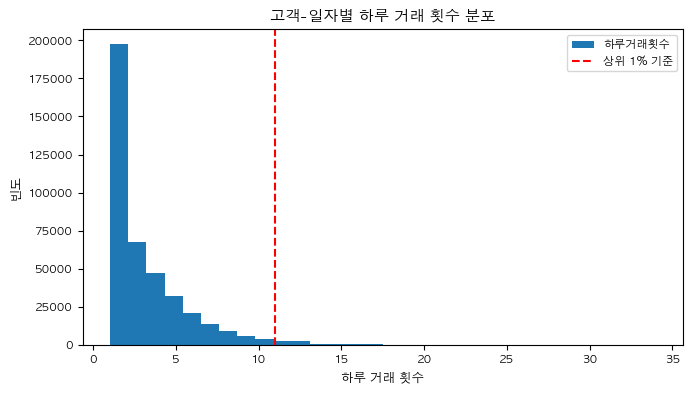

In [6]:
plt.figure(figsize=(7, 4))
customer_daily_activity["하루거래횟수"].plot(kind="hist", bins=30)
plt.axvline(high_frequency_threshold, color="red", linestyle="--", label="상위 1% 기준")
plt.title("고객-일자별 하루 거래 횟수 분포")
plt.xlabel("하루 거래 횟수")
plt.ylabel("빈도")
plt.legend()
plt.tight_layout()
plt.show()

## 4. 고객별 활동 빈도 요약

고객별 전체 활동량, 활동일수, 일평균 거래 횟수, 하루 최대 거래 횟수를 함께 봅니다.

In [7]:
customer_activity_summary = df.groupby("cc_num").agg(
    총거래횟수=("amt", "count"),
    총소비금액=("amt", "sum"),
    평균소비금액=("amt", "mean"),
    활동일수=("trans_date", "nunique"),
    사기거래횟수=("is_fraud", "sum"),
)

max_daily_count = customer_daily_activity.groupby("cc_num")["하루거래횟수"].max()
customer_activity_summary["일평균거래횟수"] = (
    customer_activity_summary["총거래횟수"] / customer_activity_summary["활동일수"]
)
customer_activity_summary["하루최대거래횟수"] = max_daily_count
customer_activity_summary["사기비율"] = (
    customer_activity_summary["사기거래횟수"] / customer_activity_summary["총거래횟수"]
)

customer_activity_summary.sort_values(
    ["하루최대거래횟수", "일평균거래횟수", "총거래횟수"],
    ascending=[False, False, False],
).head(20)

,총거래횟수,총소비금액,평균소비금액,활동일수,사기거래횟수,일평균거래횟수,하루최대거래횟수,사기비율
cc_num,,,,,,,,
3556613125071656,2556,133290.41,52.148048,510,16,5.011765,34,0.006260
4586810168620942,2918,216379.45,74.153341,516,10,5.655039,33,0.003427
4364010865167176,3011,142060.63,47.180548,525,15,5.735238,30,0.004982
3545109339866548,3113,150914.97,48.478950,519,0,5.998073,28,0.000000
6534628260579800,3112,163214.11,52.446693,528,15,5.893939,28,0.004820
3551217896304745,3055,254989.34,83.466232,524,3,5.830153,26,0.000982
4587657402165341815,2915,209256.44,71.786086,526,5,5.541825,26,0.001715
4653879239169997,2564,120945.28,47.170546,511,0,5.017613,26,0.000000
4836998673805450,3027,275930.63,91.156468,530,4,5.711321,25,0.001321


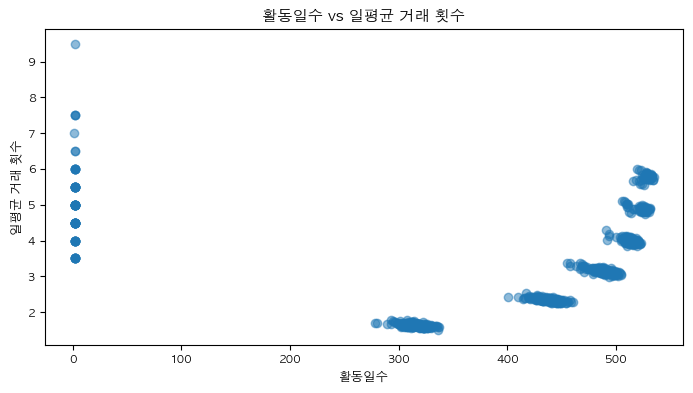

In [8]:
plt.figure(figsize=(7, 4))
plt.scatter(
    customer_activity_summary["활동일수"],
    customer_activity_summary["일평균거래횟수"],
    alpha=0.5,
)
plt.title("활동일수 vs 일평균 거래 횟수")
plt.xlabel("활동일수")
plt.ylabel("일평균 거래 횟수")
plt.tight_layout()
plt.show()

## 5. 일주일 거래 패턴

요일별 전체 거래 횟수를 확인해 평일/주말 활동 패턴을 봅니다.

In [9]:
weekday_activity = (
    df.groupby("day", observed=True)
    .agg(
        거래횟수=("amt", "count"),
        총소비금액=("amt", "sum"),
        평균소비금액=("amt", "mean"),
        사기거래횟수=("is_fraud", "sum"),
    )
    .reindex(day_order)
)

weekday_activity["사기비율"] = weekday_activity["사기거래횟수"] / weekday_activity["거래횟수"]
weekday_activity

,거래횟수,총소비금액,평균소비금액,사기거래횟수,사기비율
day,,,,,
Monday,254282,17847845.06,70.189180,1182,0.004648
Tuesday,160227,11244617.84,70.179295,935,0.005835
Wednesday,131073,9249541.86,70.567866,859,0.006554
Thursday,147285,10556820.40,71.676141,1008,0.006844
Friday,152272,10760969.63,70.669392,1079,0.007086
Saturday,200957,14183344.69,70.579003,1227,0.006106
Sunday,250579,17379289.42,69.356528,1216,0.004853


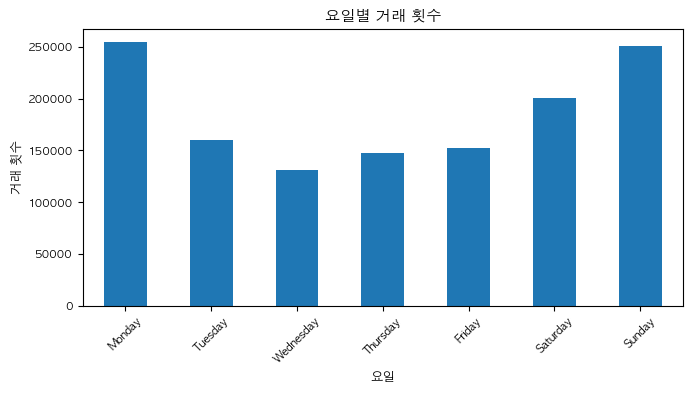

In [10]:
plt.figure(figsize=(7, 4))
weekday_activity["거래횟수"].plot(kind="bar")
plt.title("요일별 거래 횟수")
plt.xlabel("요일")
plt.ylabel("거래 횟수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. 상위 활동 고객의 요일별 패턴

전체 거래 횟수가 많은 고객 10명을 뽑고, 이들이 어떤 요일에 많이 결제하는지 비교합니다.

In [11]:
top_active_customers = customer_activity_summary.sort_values("총거래횟수", ascending=False).head(10).index

customer_weekday_pattern = (
    df[df["cc_num"].isin(top_active_customers)]
    .groupby(["cc_num", "day"], observed=True)["amt"]
    .count()
    .unstack(fill_value=0)
    .reindex(columns=day_order)
)

customer_weekday_pattern

day,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
cc_num,,,,,,,
571365235126,563,355,337,407,401,499,561
36722699017270,602,404,317,380,369,448,599
213112402583773,568,379,335,374,382,468,611
2720433095629877,688,300,224,278,317,535,765
3545109339866548,678,321,249,278,304,515,768
6011109736646996,610,378,326,354,326,483,624
6011367958204270,607,405,315,351,374,468,590
6011438889172900,619,367,336,341,386,466,591
6534628260579800,680,357,236,246,319,529,745


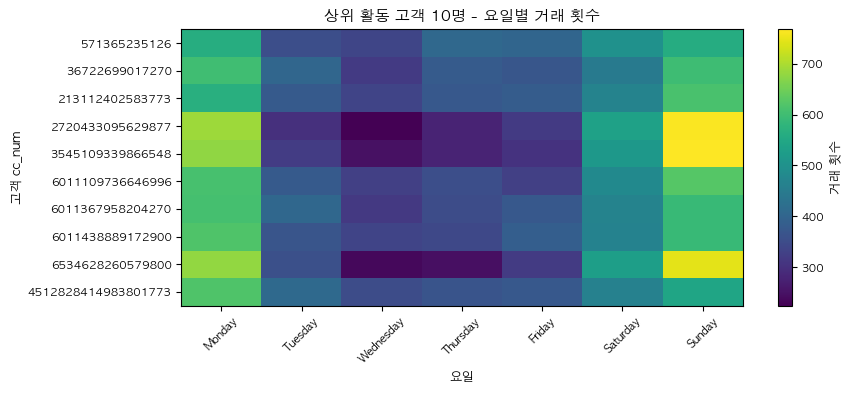

In [12]:
plt.figure(figsize=(9, 4))
plt.imshow(customer_weekday_pattern, aspect="auto")
plt.title("상위 활동 고객 10명 - 요일별 거래 횟수")
plt.xlabel("요일")
plt.ylabel("고객 cc_num")
plt.xticks(range(len(day_order)), day_order, rotation=45)
plt.yticks(range(len(customer_weekday_pattern.index)), customer_weekday_pattern.index)
plt.colorbar(label="거래 횟수")
plt.tight_layout()
plt.show()

## 7. 결과 해석

- 하루 거래 횟수가 상위 1% 기준 이상이면 활동 빈도가 매우 높은 고객-날짜 후보로 볼 수 있습니다.
- 단순히 거래가 많다고 바로 사기는 아니지만, 짧은 기간에 거래가 몰리면 카드 도용 의심 포인트가 됩니다.
- `하루최대거래횟수`가 큰 고객은 특정 날짜에 거래가 집중된 고객입니다.
- `일평균거래횟수`가 큰 고객은 평소에도 활동성이 높은 고객입니다.
- 요일별 거래 패턴은 주말 소비 증가, 평일 반복 소비 같은 생활 패턴 분석에 활용할 수 있습니다.